# Сегментация Oxford-IIIT Pet с помощью U-Net



In [ ]:
import os
import gc
import copy
import math
import random
import tarfile
import urllib.request
from pathlib import Path
from dataclasses import dataclass, asdict

import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from IPython.display import display

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader


In [ ]:
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


@dataclass
class Config:
    data_root: str = "./data"
    image_size: tuple = (128, 128)

    train_split: float = 0.8
    batch_size: int = 16
    epochs: int = 12
    learning_rate: float = 3e-4
    weight_decay: float = 1e-4

    base_channels: int = 16
    depth: int = 4
    use_batchnorm: bool = False
    dropout: float = 0.0

    num_workers: int = 2
    seed: int = 42
    device: str = "cuda" if torch.cuda.is_available() else "cpu"
    use_amp: bool = torch.cuda.is_available()

    train_subset: int | None = None
    val_subset: int | None = None
    test_subset: int | None = None

    sweep_learning_rates: tuple = (1e-3, 3e-4, 1e-4)
    sweep_batch_sizes: tuple = (8, 16, 32)
    sweep_epochs: int = 4
    final_epochs: int = 12

    def updated(self, **kwargs):
        params = asdict(self)
        params.update(kwargs)
        return Config(**params)


config = Config()
set_seed(config.seed)

print(config)


Config(data_root='./data', image_size=(128, 128), train_split=0.8, batch_size=16, epochs=12, learning_rate=0.0003, weight_decay=0.0001, base_channels=16, depth=4, use_batchnorm=False, dropout=0.0, num_workers=2, seed=42, device='cuda', use_amp=True, train_subset=None, val_subset=None, test_subset=None, sweep_learning_rates=(0.001, 0.0003, 0.0001), sweep_batch_sizes=(8, 16, 32), sweep_epochs=4, final_epochs=12)


## Датасет



In [ ]:
DATASET_URLS = {
    "images": "https://thor.robots.ox.ac.uk/~vgg/data/pets/images.tar.gz",
    "annotations": "https://thor.robots.ox.ac.uk/~vgg/data/pets/annotations.tar.gz",
}

if hasattr(Image, "Resampling"):
    BILINEAR = Image.Resampling.BILINEAR
    NEAREST = Image.Resampling.NEAREST
else:
    BILINEAR = Image.BILINEAR
    NEAREST = Image.NEAREST

if hasattr(Image, "Transpose"):
    FLIP_LEFT_RIGHT = Image.Transpose.FLIP_LEFT_RIGHT
else:
    FLIP_LEFT_RIGHT = Image.FLIP_LEFT_RIGHT


def download_oxford_pet(root: str = "./data") -> Path:
    root = Path(root)
    dataset_dir = root / "oxford-iiit-pet"
    images_dir = dataset_dir / "images"
    annotations_dir = dataset_dir / "annotations"

    dataset_dir.mkdir(parents=True, exist_ok=True)

    if images_dir.exists() and annotations_dir.exists():
        return dataset_dir

    for part_name, url in DATASET_URLS.items():
        archive_path = dataset_dir / f"{part_name}.tar.gz"

        if not archive_path.exists():
            print(f"Downloading {part_name}...")
            urllib.request.urlretrieve(url, archive_path)

        print(f"Extracting {archive_path.name}...")
        with tarfile.open(archive_path, "r:gz") as tar:
            tar.extractall(dataset_dir)

    return dataset_dir


def read_split_ids(dataset_dir: str | Path, split: str) -> list[str]:
    dataset_dir = Path(dataset_dir)
    split_file = dataset_dir / "annotations" / f"{split}.txt"

    with open(split_file, "r", encoding="utf-8") as f:
        ids = [line.strip().split()[0] for line in f if line.strip()]

    return ids


class PetSegmentationTransform:
    def __init__(
        self,
        image_size=(128, 128),
        train=False,
        mean=(0.5, 0.5, 0.5),
        std=(0.5, 0.5, 0.5),
    ):
        self.image_size = image_size
        self.train = train
        self.mean = np.array(mean, dtype=np.float32).reshape(1, 1, 3)
        self.std = np.array(std, dtype=np.float32).reshape(1, 1, 3)

    def __call__(self, image: Image.Image, mask: Image.Image):
        image = image.convert("RGB")
        mask = mask.convert("L")

        if self.train and random.random() < 0.5:
            image = image.transpose(FLIP_LEFT_RIGHT)
            mask = mask.transpose(FLIP_LEFT_RIGHT)

        image = image.resize(self.image_size, BILINEAR)
        mask = mask.resize(self.image_size, NEAREST)

        image = np.asarray(image).astype(np.float32) / 255.0
        image = (image - self.mean) / self.std
        image = torch.from_numpy(image).permute(2, 0, 1)

        mask = np.asarray(mask).astype(np.uint8)
        mask = (mask != 2).astype(np.float32)
        mask = torch.from_numpy(mask).unsqueeze(0)

        return image, mask


class OxfordPetSegmentationDataset(Dataset):
    def __init__(self, root="./data", split="trainval", image_ids=None, transform=None, download=True):
        self.dataset_dir = download_oxford_pet(root) if download else Path(root) / "oxford-iiit-pet"
        self.transform = transform

        all_ids = read_split_ids(self.dataset_dir, split)
        self.image_ids = image_ids if image_ids is not None else all_ids

        self.images_dir = self.dataset_dir / "images"
        self.masks_dir = self.dataset_dir / "annotations" / "trimaps"

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        image_id = self.image_ids[idx]

        image = Image.open(self.images_dir / f"{image_id}.jpg").convert("RGB")
        mask = Image.open(self.masks_dir / f"{image_id}.png")

        if self.transform is not None:
            image, mask = self.transform(image, mask)

        return image, mask


def denormalize_image(image_tensor: torch.Tensor) -> np.ndarray:
    image = image_tensor.detach().cpu().permute(1, 2, 0).numpy()
    image = image * 0.5 + 0.5
    image = np.clip(image, 0.0, 1.0)
    return image


def show_dataset_samples(dataset, n_samples=3):
    fig, axes = plt.subplots(n_samples, 2, figsize=(8, 3 * n_samples))

    if n_samples == 1:
        axes = np.array([axes])

    for i in range(n_samples):
        image, mask = dataset[i]
        axes[i, 0].imshow(denormalize_image(image))
        axes[i, 0].set_title("Image")
        axes[i, 0].axis("off")

        axes[i, 1].imshow(mask.squeeze(0).numpy(), cmap="gray")
        axes[i, 1].set_title("Mask")
        axes[i, 1].axis("off")

    plt.tight_layout()
    plt.show()


Extracting images.tar.gz...


/tmp/ipykernel_584/4273043156.py:39: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(dataset_dir)


Extracting annotations.tar.gz...


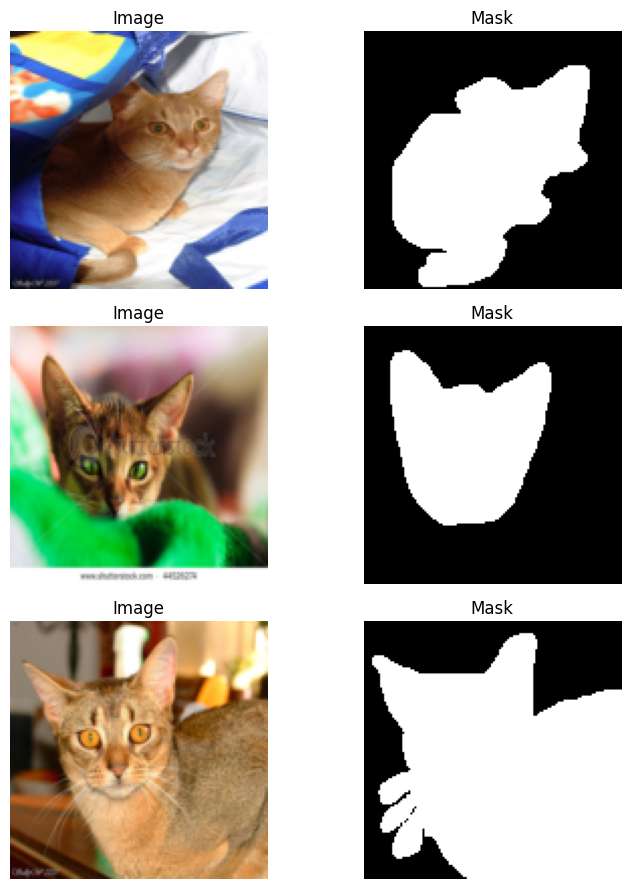

In [ ]:
dataset_dir = download_oxford_pet(config.data_root)
train_preview = OxfordPetSegmentationDataset(
    root=config.data_root,
    split="trainval",
    transform=PetSegmentationTransform(config.image_size, train=False),
    download=False,
)
show_dataset_samples(train_preview, n_samples=3)


## Модель U-Net



In [ ]:
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch, use_batchnorm=False, dropout=0.0):
        super().__init__()

        layers = [
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=not use_batchnorm)
        ]
        if use_batchnorm:
            layers.append(nn.BatchNorm2d(out_ch))
        layers.append(nn.ReLU(inplace=True))

        if dropout > 0:
            layers.append(nn.Dropout2d(dropout))

        layers.append(nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1, bias=not use_batchnorm))
        if use_batchnorm:
            layers.append(nn.BatchNorm2d(out_ch))
        layers.append(nn.ReLU(inplace=True))

        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)


class UNet(nn.Module):
    def __init__(
        self,
        in_channels=3,
        out_channels=1,
        base_channels=16,
        depth=4,
        use_batchnorm=False,
        dropout=0.0,
    ):
        super().__init__()

        self.down_blocks = nn.ModuleList()
        self.pools = nn.ModuleList()

        current_in = in_channels
        current_out = base_channels

        for _ in range(depth):
            self.down_blocks.append(
                DoubleConv(
                    current_in,
                    current_out,
                    use_batchnorm=use_batchnorm,
                    dropout=dropout,
                )
            )
            self.pools.append(nn.MaxPool2d(2))
            current_in = current_out
            current_out *= 2

        self.bottleneck = DoubleConv(
            current_in,
            current_out,
            use_batchnorm=use_batchnorm,
            dropout=dropout,
        )

        self.up_transpose = nn.ModuleList()
        self.up_blocks = nn.ModuleList()

        decoder_in = current_out
        for level in reversed(range(depth)):
            decoder_out = base_channels * (2 ** level)
            self.up_transpose.append(
                nn.ConvTranspose2d(decoder_in, decoder_out, kernel_size=2, stride=2)
            )
            self.up_blocks.append(
                DoubleConv(
                    decoder_out * 2,
                    decoder_out,
                    use_batchnorm=use_batchnorm,
                    dropout=dropout,
                )
            )
            decoder_in = decoder_out

        self.final_conv = nn.Conv2d(base_channels, out_channels, kernel_size=1)

    def forward(self, x):
        skips = []

        for down_block, pool in zip(self.down_blocks, self.pools):
            x = down_block(x)
            skips.append(x)
            x = pool(x)

        x = self.bottleneck(x)

        for up_t, up_block, skip in zip(self.up_transpose, self.up_blocks, reversed(skips)):
            x = up_t(x)

            if x.shape[-2:] != skip.shape[-2:]:
                x = F.interpolate(x, size=skip.shape[-2:], mode="bilinear", align_corners=False)

            x = torch.cat([skip, x], dim=1)
            x = up_block(x)

        return self.final_conv(x)


model = UNet(
    base_channels=config.base_channels,
    depth=config.depth,
    use_batchnorm=config.use_batchnorm,
    dropout=config.dropout,
)
print(model.__class__.__name__)
print(f"Parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")


UNet
Parameters: 1,941,105


## Лосс, метрики и trainer



In [ ]:
class BCEDiceLoss(nn.Module):
    def __init__(self, bce_weight=0.5, smooth=1.0):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss()
        self.bce_weight = bce_weight
        self.smooth = smooth

    def forward(self, logits, targets):
        bce = self.bce(logits, targets)

        probs = torch.sigmoid(logits).flatten(1)
        targets = targets.flatten(1)

        intersection = (probs * targets).sum(dim=1)
        dice = (2 * intersection + self.smooth) / (
            probs.sum(dim=1) + targets.sum(dim=1) + self.smooth
        )
        dice_loss = 1 - dice.mean()

        return self.bce_weight * bce + (1 - self.bce_weight) * dice_loss


def batch_iou_f1_from_logits(logits, targets, threshold=0.5, eps=1e-7):
    probs = torch.sigmoid(logits)
    preds = (probs >= threshold).float()
    targets = (targets >= 0.5).float()

    preds = preds.flatten(1)
    targets = targets.flatten(1)

    intersection = (preds * targets).sum(dim=1)
    union = preds.sum(dim=1) + targets.sum(dim=1) - intersection

    iou = ((intersection + eps) / (union + eps)).mean().item()
    f1 = ((2 * intersection + eps) / (preds.sum(dim=1) + targets.sum(dim=1) + eps)).mean().item()

    return iou, f1


def cleanup_memory():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


class Trainer:
    def __init__(self, config: Config):
        self.config = config
        self.device = torch.device(config.device)
        set_seed(config.seed)

        self.model = UNet(
            in_channels=3,
            out_channels=1,
            base_channels=config.base_channels,
            depth=config.depth,
            use_batchnorm=config.use_batchnorm,
            dropout=config.dropout,
        ).to(self.device)

        self.criterion = BCEDiceLoss()
        self.optimizer = torch.optim.Adam(
            self.model.parameters(),
            lr=config.learning_rate,
            weight_decay=config.weight_decay,
        )
        self.scaler = torch.amp.GradScaler("cuda", enabled=config.use_amp)

        self.history = {
            "train_loss": [],
            "val_loss": [],
            "val_iou": [],
            "val_f1": [],
        }
        self.best_val_iou = -1.0
        self.best_state_dict = None
        self.test_metrics = None

        self.setup_dataloaders()

    def setup_dataloaders(self):
        dataset_dir = download_oxford_pet(self.config.data_root)
        full_ids = read_split_ids(dataset_dir, "trainval")

        rng = np.random.default_rng(self.config.seed)
        indices = rng.permutation(len(full_ids))
        train_size = int(self.config.train_split * len(full_ids))

        train_ids = [full_ids[i] for i in indices[:train_size]]
        val_ids = [full_ids[i] for i in indices[train_size:]]

        if self.config.train_subset is not None:
            train_ids = train_ids[: self.config.train_subset]
        if self.config.val_subset is not None:
            val_ids = val_ids[: self.config.val_subset]

        test_ids = read_split_ids(dataset_dir, "test")
        if self.config.test_subset is not None:
            test_ids = test_ids[: self.config.test_subset]

        train_transform = PetSegmentationTransform(self.config.image_size, train=True)
        eval_transform = PetSegmentationTransform(self.config.image_size, train=False)

        self.train_dataset = OxfordPetSegmentationDataset(
            root=self.config.data_root,
            split="trainval",
            image_ids=train_ids,
            transform=train_transform,
            download=False,
        )
        self.val_dataset = OxfordPetSegmentationDataset(
            root=self.config.data_root,
            split="trainval",
            image_ids=val_ids,
            transform=eval_transform,
            download=False,
        )
        self.test_dataset = OxfordPetSegmentationDataset(
            root=self.config.data_root,
            split="test",
            image_ids=test_ids,
            transform=eval_transform,
            download=False,
        )

        loader_kwargs = {
            "batch_size": self.config.batch_size,
            "num_workers": self.config.num_workers,
            "pin_memory": self.device.type == "cuda",
        }
        if self.config.num_workers > 0:
            loader_kwargs["persistent_workers"] = True

        self.train_loader = DataLoader(self.train_dataset, shuffle=True, **loader_kwargs)
        self.val_loader = DataLoader(self.val_dataset, shuffle=False, **loader_kwargs)
        self.test_loader = DataLoader(self.test_dataset, shuffle=False, **loader_kwargs)

    def train_one_epoch(self):
        self.model.train()
        total_loss = 0.0

        for images, masks in tqdm(self.train_loader, leave=False):
            images = images.to(self.device, non_blocking=True)
            masks = masks.to(self.device, non_blocking=True)

            self.optimizer.zero_grad(set_to_none=True)

            with torch.amp.autocast("cuda", enabled=self.config.use_amp):
                logits = self.model(images)
                loss = self.criterion(logits, masks)

            self.scaler.scale(loss).backward()
            self.scaler.step(self.optimizer)
            self.scaler.update()

            total_loss += loss.item() * images.size(0)

        return total_loss / len(self.train_dataset)

    def evaluate(self, loader):
        self.model.eval()
        total_loss = 0.0
        total_iou = 0.0
        total_f1 = 0.0
        total_items = 0

        with torch.no_grad():
            for images, masks in tqdm(loader, leave=False):
                images = images.to(self.device, non_blocking=True)
                masks = masks.to(self.device, non_blocking=True)

                with torch.amp.autocast("cuda", enabled=self.config.use_amp):
                    logits = self.model(images)
                    loss = self.criterion(logits, masks)

                batch_size = images.size(0)
                iou, f1 = batch_iou_f1_from_logits(logits, masks)

                total_loss += loss.item() * batch_size
                total_iou += iou * batch_size
                total_f1 += f1 * batch_size
                total_items += batch_size

        return total_loss / total_items, total_iou / total_items, total_f1 / total_items

    def fit(self):
        for epoch in range(1, self.config.epochs + 1):
            train_loss = self.train_one_epoch()
            val_loss, val_iou, val_f1 = self.evaluate(self.val_loader)

            self.history["train_loss"].append(train_loss)
            self.history["val_loss"].append(val_loss)
            self.history["val_iou"].append(val_iou)
            self.history["val_f1"].append(val_f1)

            if val_iou > self.best_val_iou:
                self.best_val_iou = val_iou
                self.best_state_dict = copy.deepcopy(self.model.state_dict())

            print(
                f"Epoch {epoch:02d}/{self.config.epochs} | "
                f"train_loss={train_loss:.4f} | "
                f"val_loss={val_loss:.4f} | "
                f"val_iou={val_iou:.4f} | "
                f"val_f1={val_f1:.4f}"
            )

        if self.best_state_dict is not None:
            self.model.load_state_dict(self.best_state_dict)

        test_loss, test_iou, test_f1 = self.evaluate(self.test_loader)
        self.test_metrics = {
            "test_loss": test_loss,
            "test_iou": test_iou,
            "test_f1": test_f1,
        }

        print(
            f"Test | loss={test_loss:.4f} | iou={test_iou:.4f} | f1={test_f1:.4f}"
        )

        return {
            "history": self.history,
            "best_val_iou": self.best_val_iou,
            **self.test_metrics,
        }

    def plot_history(self, title_prefix=""):
        epochs = range(1, len(self.history["train_loss"]) + 1)

        plt.figure(figsize=(8, 4))
        plt.plot(epochs, self.history["train_loss"], label="train_loss")
        plt.plot(epochs, self.history["val_loss"], label="val_loss")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title(f"{title_prefix} Loss")
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.show()

        plt.figure(figsize=(8, 4))
        plt.plot(epochs, self.history["val_iou"], label="val_iou")
        plt.plot(epochs, self.history["val_f1"], label="val_f1")
        plt.xlabel("Epoch")
        plt.ylabel("Metric")
        plt.title(f"{title_prefix} Validation metrics")
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.show()

    def inference_and_plot_samples(self, n_samples=3):
        self.model.eval()

        indices = np.linspace(0, len(self.test_dataset) - 1, n_samples, dtype=int)
        fig, axes = plt.subplots(n_samples, 3, figsize=(10, 3 * n_samples))

        if n_samples == 1:
            axes = np.array([axes])

        with torch.no_grad():
            for row, idx in enumerate(indices):
                image, mask = self.test_dataset[idx]
                logits = self.model(image.unsqueeze(0).to(self.device))
                pred_mask = (torch.sigmoid(logits).squeeze().cpu().numpy() >= 0.5).astype(np.float32)

                axes[row, 0].imshow(denormalize_image(image))
                axes[row, 0].set_title("Image")
                axes[row, 0].axis("off")

                axes[row, 1].imshow(mask.squeeze(0).numpy(), cmap="gray")
                axes[row, 1].set_title("Ground truth")
                axes[row, 1].axis("off")

                axes[row, 2].imshow(pred_mask, cmap="gray")
                axes[row, 2].set_title("Prediction")
                axes[row, 2].axis("off")

        plt.tight_layout()
        plt.show()


## Базовый запуск

Обучаем обычный U-Net без дополнительных модификаций, эта модель потом будет служить базой для сравнения


Epoch 01/12 | train_loss=0.6074 | val_loss=0.5563 | val_iou=0.4976 | val_f1=0.6441


Epoch 02/12 | train_loss=0.4770 | val_loss=0.4516 | val_iou=0.5642 | val_f1=0.7070


Epoch 03/12 | train_loss=0.4419 | val_loss=0.4403 | val_iou=0.5772 | val_f1=0.7172


Epoch 04/12 | train_loss=0.4216 | val_loss=0.4158 | val_iou=0.5830 | val_f1=0.7220


Epoch 05/12 | train_loss=0.4049 | val_loss=0.3850 | val_iou=0.6158 | val_f1=0.7499


...

Epoch 09/12 | train_loss=0.3412 | val_loss=0.3279 | val_iou=0.6724 | val_f1=0.7916


Epoch 10/12 | train_loss=0.3359 | val_loss=0.3345 | val_iou=0.6703 | val_f1=0.7896


Epoch 11/12 | train_loss=0.3248 | val_loss=0.3318 | val_iou=0.6702 | val_f1=0.7892


Epoch 12/12 | train_loss=0.3236 | val_loss=0.3326 | val_iou=0.6773 | val_f1=0.7932


Test | loss=0.3149 | iou=0.6930 | f1=0.8050


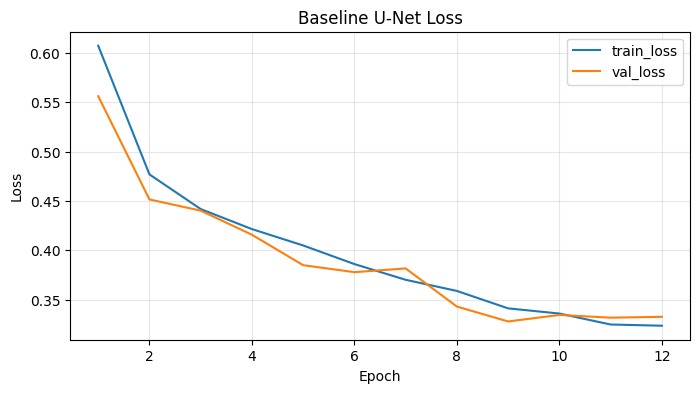

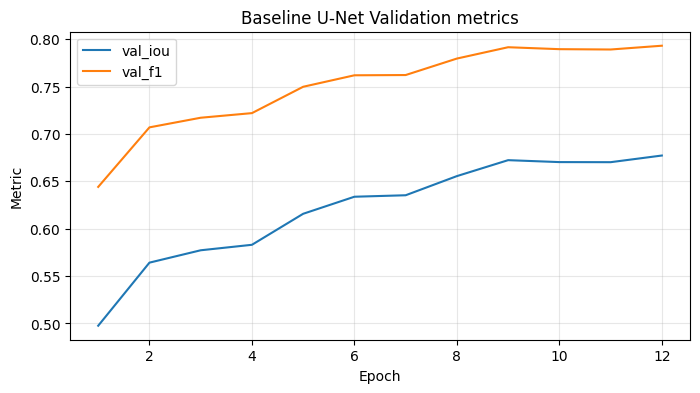

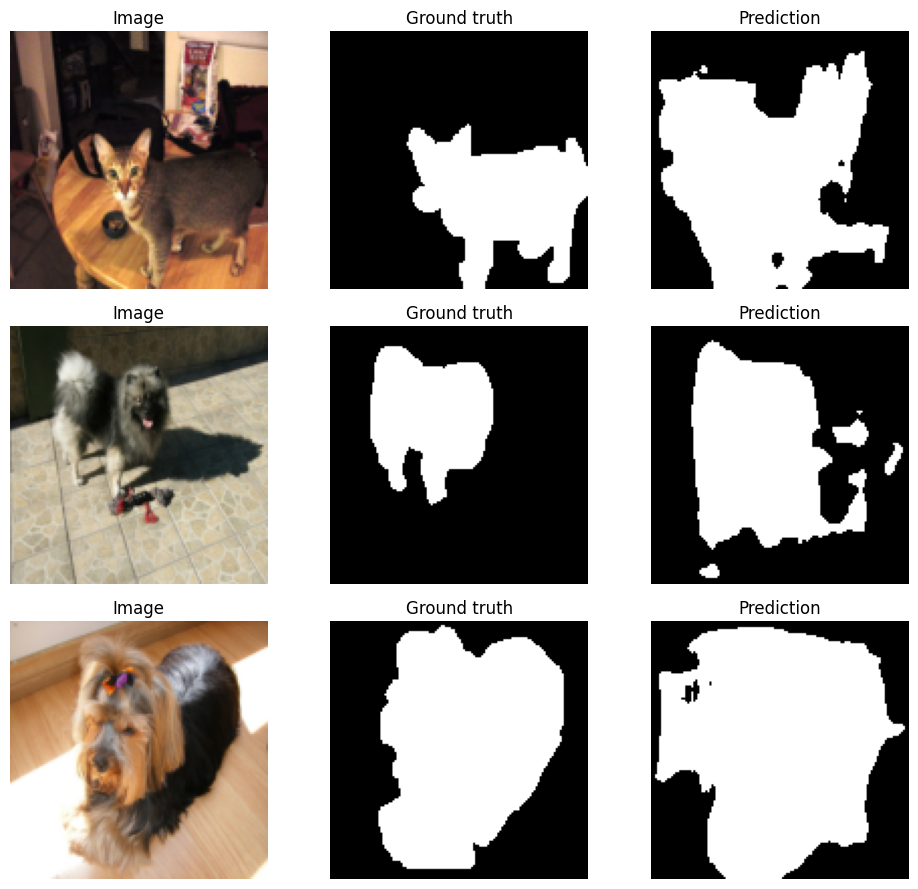

In [ ]:
baseline_config = config.updated(
    epochs=config.final_epochs,
    base_channels=16,
    depth=4,
    use_batchnorm=False,
    dropout=0.0,
)

baseline_trainer = Trainer(baseline_config)
baseline_result = baseline_trainer.fit()

baseline_trainer.plot_history("Baseline U-Net")
baseline_trainer.inference_and_plot_samples(n_samples=3)


## Перебор гиперпараметров

Чтобы перебор не занимал слишком много времени, для него число эпох уменьшено до sweep_epochs


Run: lr=0.001, batch_size=8


Epoch 01/4 | train_loss=0.5479 | val_loss=0.4750 | val_iou=0.5367 | val_f1=0.6791


Epoch 02/4 | train_loss=0.4590 | val_loss=0.4328 | val_iou=0.5875 | val_f1=0.7229


Epoch 03/4 | train_loss=0.4362 | val_loss=0.4389 | val_iou=0.5930 | val_f1=0.7262


Epoch 04/4 | train_loss=0.4116 | val_loss=0.3991 | val_iou=0.6179 | val_f1=0.7502


...

Epoch 02/4 | train_loss=0.6232 | val_loss=0.6051 | val_iou=0.4537 | val_f1=0.6032


Epoch 03/4 | train_loss=0.5626 | val_loss=0.5208 | val_iou=0.5180 | val_f1=0.6657


Epoch 04/4 | train_loss=0.4822 | val_loss=0.4441 | val_iou=0.5565 | val_f1=0.7050


Test | loss=0.4422 | iou=0.5624 | f1=0.7099


,learning_rate,batch_size,best_val_iou,test_iou,test_f1,test_loss
0,0.0010,8,0.617871,0.630601,0.759627,0.386198
1,0.0003,8,0.604510,0.612632,0.747306,0.394725
2,0.0003,16,0.583025,0.594668,0.732453,0.407372
3,0.0010,16,0.572563,0.593977,0.726002,0.444481
4,0.0001,16,0.571543,0.579236,0.723204,0.414061
5,0.0003,32,0.569583,0.583044,0.723819,0.427477
6,0.0001,8,0.564508,0.568952,0.713861,0.430017
7,0.0001,32,0.556498,0.562450,0.709900,0.442250
8,0.0010,32,0.554427,0.577066,0.712665,0.458015


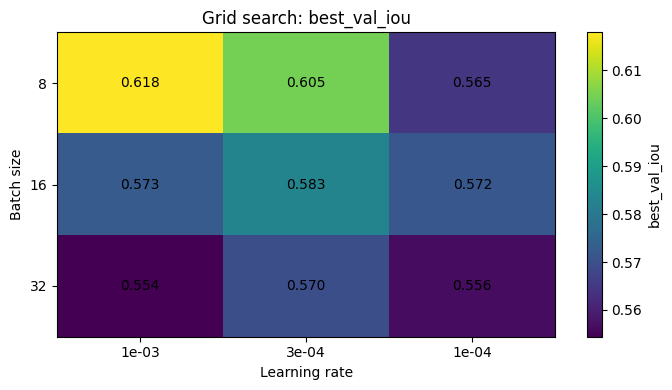

In [ ]:
def run_grid_search(base_config: Config, learning_rates, batch_sizes):
    rows = []

    for lr in learning_rates:
        for batch_size in batch_sizes:
            cleanup_memory()

            exp_config = base_config.updated(
                learning_rate=lr,
                batch_size=batch_size,
                epochs=base_config.sweep_epochs,
            )

            print("=" * 80)
            print(f"Run: lr={lr}, batch_size={batch_size}")

            trainer = Trainer(exp_config)
            result = trainer.fit()

            rows.append(
                {
                    "learning_rate": lr,
                    "batch_size": batch_size,
                    "best_val_iou": result["best_val_iou"],
                    "test_iou": result["test_iou"],
                    "test_f1": result["test_f1"],
                    "test_loss": result["test_loss"],
                }
            )

            del trainer
            cleanup_memory()

    results_df = pd.DataFrame(rows).sort_values("best_val_iou", ascending=False).reset_index(drop=True)
    return results_df


def plot_sweep_heatmap(results_df, metric="best_val_iou"):
    pivot = results_df.pivot(index="batch_size", columns="learning_rate", values=metric)
    pivot = pivot.sort_index().reindex(sorted(pivot.columns, reverse=True), axis=1)

    plt.figure(figsize=(7, 4))
    plt.imshow(pivot.values, aspect="auto")
    plt.colorbar(label=metric)

    plt.xticks(range(len(pivot.columns)), [f"{x:.0e}" for x in pivot.columns])
    plt.yticks(range(len(pivot.index)), pivot.index)

    for i in range(len(pivot.index)):
        for j in range(len(pivot.columns)):
            value = pivot.iloc[i, j]
            plt.text(j, i, f"{value:.3f}", ha="center", va="center")

    plt.xlabel("Learning rate")
    plt.ylabel("Batch size")
    plt.title(f"Grid search: {metric}")
    plt.tight_layout()
    plt.show()


sweep_base_config = config.updated(
    epochs=config.sweep_epochs,
    base_channels=16,
    depth=4,
    use_batchnorm=False,
    dropout=0.0,
)

sweep_results = run_grid_search(
    sweep_base_config,
    learning_rates=config.sweep_learning_rates,
    batch_sizes=config.sweep_batch_sizes,
)

display(sweep_results)
plot_sweep_heatmap(sweep_results, metric="best_val_iou")


Был проведён перебор гиперпараметров learning rate и batch size. По результатам экспериментов наилучшее качество (val IoU ≈ 0.618) показала модель с параметрами lr = 1e-3 и batch_size = 8.

Увеличение learning rate с 1e-4 до 1e-3 приводило к улучшению качества, что связано с тем, что при малом числе эпох более высокий шаг обучения позволяет быстрее сходиться.

Увеличение batch size приводило к ухудшению качества модели. Это можно объяснить тем, что меньший batch size даёт более шумные градиенты, что способствует лучшей обобщающей способности модели.

Также наблюдается зависимость между параметрами: при увеличении batch size эффективность высокого learning rate снижается.

В целом, наилучшие результаты достигаются при сочетании большого learning rate и малого batch size.

In [ ]:
best_row = sweep_results.iloc[0]
best_lr = float(best_row["learning_rate"])
best_batch_size = int(best_row["batch_size"])

print(f"Лучшие гиперпараметры по val IoU: lr={best_lr}, batch_size={best_batch_size}")


Лучшие гиперпараметры по val IoU: lr=0.001, batch_size=8


## Проверка идеи по модификации U-Net

Проверяем такую идею:
- сделать сеть глубже
- добавить BatchNorm
- добавить небольшой Dropout

Ожидание: обучение должно стать стабильнее, а качество на валидации и тесте — выше или хотя бы не хуже, чем у базовой модели.


Epoch 01/12 | train_loss=0.5479 | val_loss=0.4750 | val_iou=0.5367 | val_f1=0.6791


Epoch 02/12 | train_loss=0.4590 | val_loss=0.4328 | val_iou=0.5875 | val_f1=0.7229


Epoch 03/12 | train_loss=0.4362 | val_loss=0.4389 | val_iou=0.5930 | val_f1=0.7262


Epoch 04/12 | train_loss=0.4116 | val_loss=0.3991 | val_iou=0.6179 | val_f1=0.7502


Epoch 05/12 | train_loss=0.3959 | val_loss=0.4863 | val_iou=0.5729 | val_f1=0.7078


...

Epoch 10/12 | train_loss=0.2361 | val_loss=0.2138 | val_iou=0.7833 | val_f1=0.8687


Epoch 11/12 | train_loss=0.2294 | val_loss=0.2038 | val_iou=0.7897 | val_f1=0.8732


Epoch 12/12 | train_loss=0.2215 | val_loss=0.2000 | val_iou=0.7968 | val_f1=0.8786


Test | loss=0.1989 | iou=0.7997 | f1=0.8807


,model,best_val_iou,test_iou,test_f1,test_loss
0,baseline_unet,0.662150,0.678687,0.794562,0.339333
1,deep_bn_dropout_unet,0.796759,0.799659,0.880698,0.198902


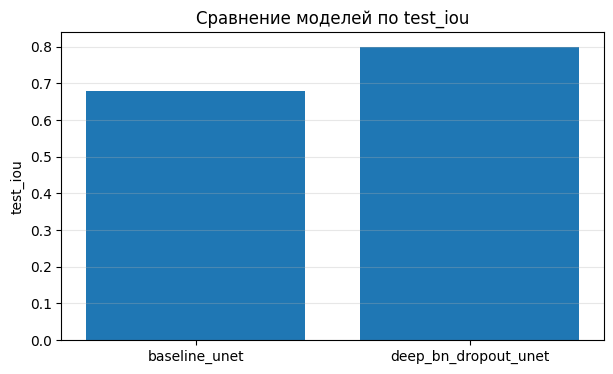

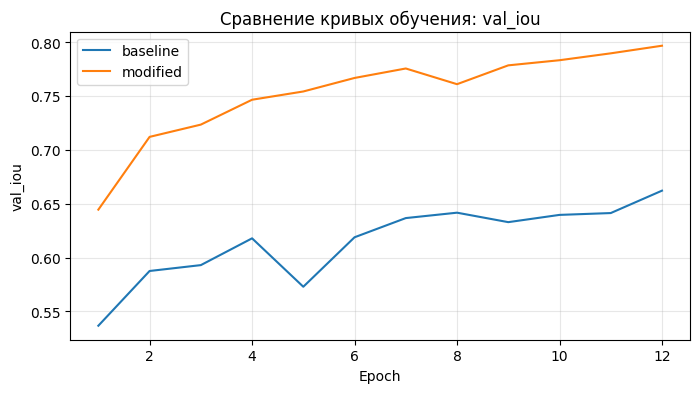

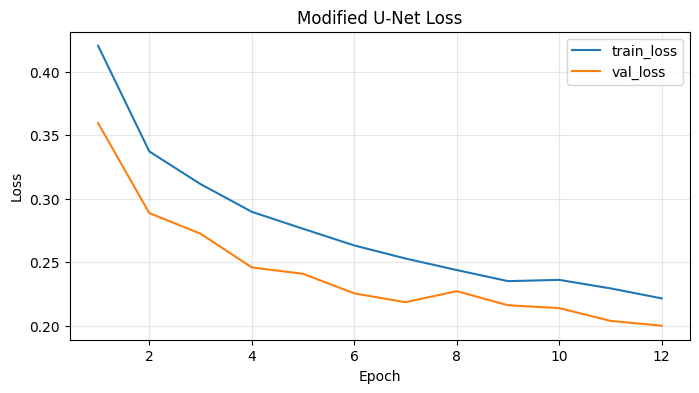

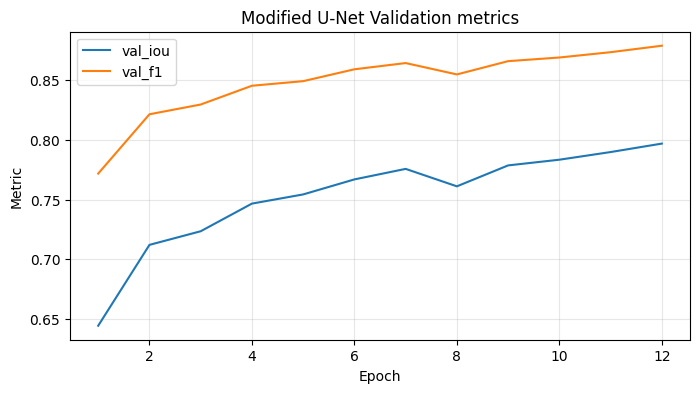

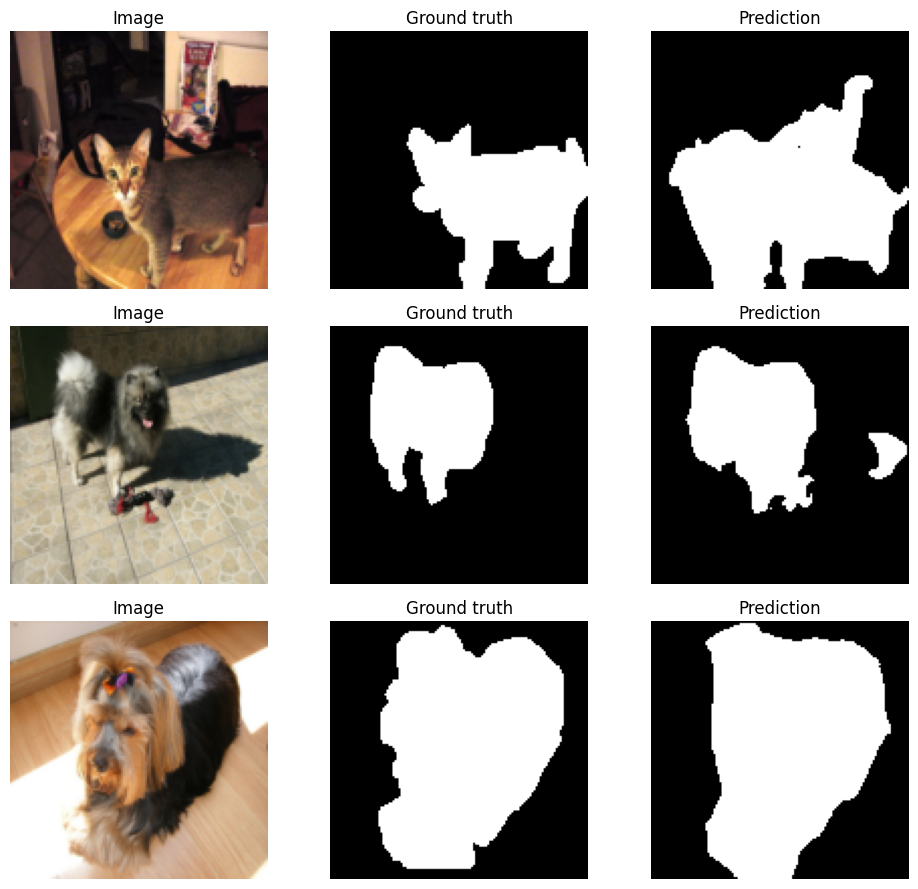

In [ ]:
def plot_model_comparison(compare_df, metric="test_iou"):
    plt.figure(figsize=(7, 4))
    plt.bar(compare_df["model"], compare_df[metric])
    plt.ylabel(metric)
    plt.title(f"Сравнение моделей по {metric}")
    plt.grid(True, axis="y", alpha=0.3)
    plt.show()


def plot_history_comparison(history_a, history_b, label_a="baseline", label_b="modified", metric="val_iou"):
    epochs_a = range(1, len(history_a[metric]) + 1)
    epochs_b = range(1, len(history_b[metric]) + 1)

    plt.figure(figsize=(8, 4))
    plt.plot(epochs_a, history_a[metric], label=label_a)
    plt.plot(epochs_b, history_b[metric], label=label_b)
    plt.xlabel("Epoch")
    plt.ylabel(metric)
    plt.title(f"Сравнение кривых обучения: {metric}")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()


baseline_best_config = config.updated(
    epochs=config.final_epochs,
    learning_rate=best_lr,
    batch_size=best_batch_size,
    base_channels=16,
    depth=4,
    use_batchnorm=False,
    dropout=0.0,
)

modified_config = config.updated(
    epochs=config.final_epochs,
    learning_rate=best_lr,
    batch_size=best_batch_size,
    base_channels=16,
    depth=5,
    use_batchnorm=True,
    dropout=0.1,
)

cleanup_memory()
baseline_best_trainer = Trainer(baseline_best_config)
baseline_best_result = baseline_best_trainer.fit()

cleanup_memory()
modified_trainer = Trainer(modified_config)
modified_result = modified_trainer.fit()

compare_df = pd.DataFrame(
    [
        {
            "model": "baseline_unet",
            "best_val_iou": baseline_best_result["best_val_iou"],
            "test_iou": baseline_best_result["test_iou"],
            "test_f1": baseline_best_result["test_f1"],
            "test_loss": baseline_best_result["test_loss"],
        },
        {
            "model": "deep_bn_dropout_unet",
            "best_val_iou": modified_result["best_val_iou"],
            "test_iou": modified_result["test_iou"],
            "test_f1": modified_result["test_f1"],
            "test_loss": modified_result["test_loss"],
        },
    ]
)

display(compare_df)
plot_model_comparison(compare_df, metric="test_iou")
plot_history_comparison(
    baseline_best_trainer.history,
    modified_trainer.history,
    label_a="baseline",
    label_b="modified",
    metric="val_iou",
)

modified_trainer.plot_history("Modified U-Net")
modified_trainer.inference_and_plot_samples(n_samples=3)


Для улучшения качества сегментации была проверена модификация U-Net, включающая увеличение глубины сети, добавление Batch Normalization и Dropout.

Увеличение глубины (depth=5) позволило модели извлекать более сложные и абстрактные признаки, что особенно важно для сегментации объектов с разнообразной формой и текстурой.

Добавление Batch Normalization стабилизировало процесс обучения и ускорило сходимость, что видно по более быстрому росту метрик на ранних эпохах.

Использование Dropout (0.1) позволило снизить риск переобучения и улучшить обобщающую способность модели.

В результате модифицированная модель показала значительное улучшение качества: значение IoU на тестовой выборке увеличилось с ~0.68 до ~0.80, а F1 — с ~0.79 до ~0.88.

Также улучшилось визуальное качество предсказаний: границы объектов стали более точными, уменьшилось количество лишних областей и артефактов.

Таким образом, предложенные изменения архитектуры существенно повысили качество сегментации.
